In [1]:
import sys, glob, os, yaml, sparse, tracemalloc, vcf, subprocess, collections
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy.stats as st
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

from dna_features_viewer import BiopythonTranslator, GraphicFeature, GraphicRecord
from dna_features_viewer.biotools import annotate_biopython_record
import itertools, difflib

import warnings
warnings.filterwarnings("ignore")

who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from data_utils import *
import Bio.SeqUtils
from Bio import Seq, SeqIO

cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETH",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMI",
                  "Pretomanid": "PTM",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LEV",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {val: key for (key, val) in drug_abbr_dict.items()}

lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineages.csv")
lineages.shape

4411532


(13007, 7)

# Train vs. Validation MIC Distributions (HISTOGRAMS)

In [2]:
def plot_MIC_dist(drug, cc, saveName=None):
    
    df_combined = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv"))

    # if os.path.isfile(os.path.join(data_dir, drug, "validation_data_for_model.csv")):
    #     val_present = True
    #     df_val = pd.read_csv(os.path.join(data_dir, drug, "validation_data_for_model.csv"))
    # else:
    #     val_present = False
    #     df_val = pd.DataFrame(columns=["ROLLINGDB_ID", f"{drug}_midpoint"])
    
    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    val_present = False

    # df_val["category"] = "Validation"
    # df_combined = pd.concat([df_train[["category", f"{drug}_midpoint"]], df_val[["category", f"{drug}_midpoint"]]])
    df_combined.rename(columns={"category": "Dataset"}, inplace=True)

    if val_present:
        df_combined["Dataset"] = df_combined["Dataset"].replace("original_train_set", "Train").replace("original_test_set", "Train")
        hue_order = ["Train", "Validation"]
    else:
        df_combined["Dataset"] = df_combined["Dataset"].replace("original_train_set", "Train").replace("original_test_set", "Test")
        hue_order = ["Train", "Test"]

    # print p-value for difference between distributions using Kolmogorov-Smirnov test, which is non-parametric
    _, pval = st.ks_2samp(df_combined.query("Dataset=='Train'")[f"{drug}_midpoint"],
                          df_combined.query("Dataset=='Test'")[f"{drug}_midpoint"],
                          alternative='two-sided'
                         )

    print(f"K-S Test p-value: {pval}")
    
    sns.histplot(data=df_combined, 
                 x=f"{drug}_midpoint", 
                 hue="Dataset", 
                 hue_order=hue_order,
                 common_norm=False, 
                 common_bins=True,
                 element="bars",
                 stat="probability", 
                 multiple="dodge",
                 #kde=True,
                 fill=True,
                 line_kws={"linecolor": "black", "linewidth": 1},
                 palette="Set2", 
                 ax=ax, 
                 log_scale=2,
                 legend=True
                )

    # Get the handles and labels from both legends
    handles, labels = plt.gca().get_legend().legendHandles, [t.get_text() for t in plt.gca().get_legend().get_texts()]
    
    # Add a legend that combines the handles and labels
    plt.legend(handles=handles + [plt.axvline(cc, color="black", linestyle="dashed", label=f"CC = {cc}")], labels=labels + [f"CC = {cc}"])
    plt.title(f"{abbr_drug_dict[drug]}, N = {len(df_combined)}")
    plt.xlabel("MIC (µg/mL)")
    sns.despine()
    
    if saveName is not None:
        plt.savefig(saveName, dpi=300)
    else:
        plt.show()

In [3]:
# fNames = []

# for isolate in df.ROLLINGDB_ID.values:

#     fName = f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/{isolate}/pilon/{isolate}.eff.vcf"
#     assert os.path.isfile(fName)
#     fNames.append(fName)

# print(len(fNames))
# pd.Series(fNames).to_csv(f"../mutation_splitting/{drug}_VCF_paths.txt", sep="\t", index=False, header=None)

In [27]:
drug = 'MXF'
df = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv"))
df[f'{drug}_upper_bound'].min(), df[f'{drug}_lower_bound'].max(), df[f'{drug}_midpoint'].mean()

(0.03, 10.0, 0.425847703085006)

In [28]:
df.Binary.sum(), df.Binary.mean()

(1190, 0.16031254209888185)

K-S Test p-value: 0.999999992815811


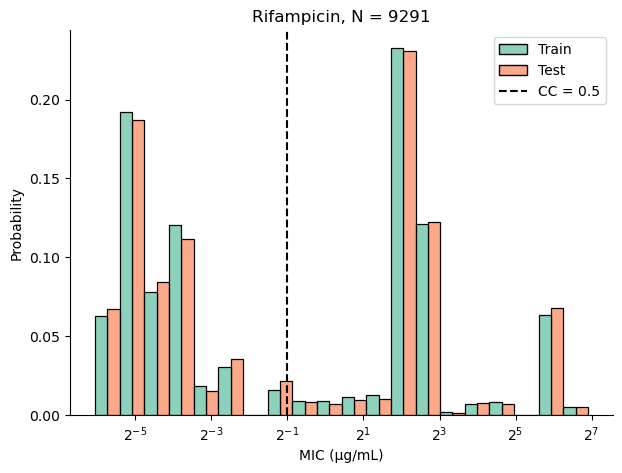

In [4]:
plot_MIC_dist("RIF", 0.5, saveName="../analysis/Rifampicin/train_test_MICs.png")

K-S Test p-value: 0.9969181260800654


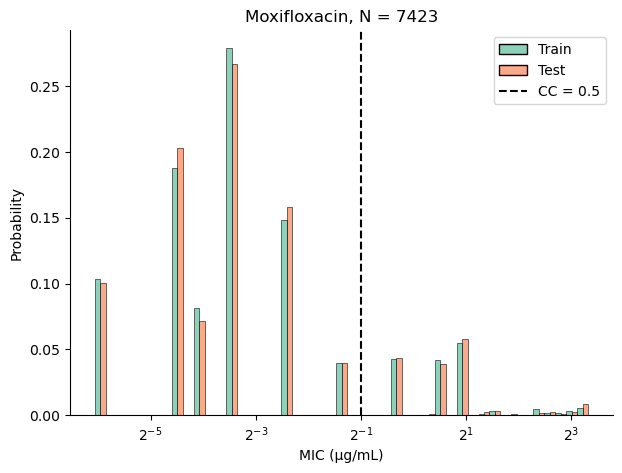

In [5]:
plot_MIC_dist("MXF", 0.5, saveName="../analysis/Moxifloxacin/train_test_MICs.png")

K-S Test p-value: 0.9999998952439341


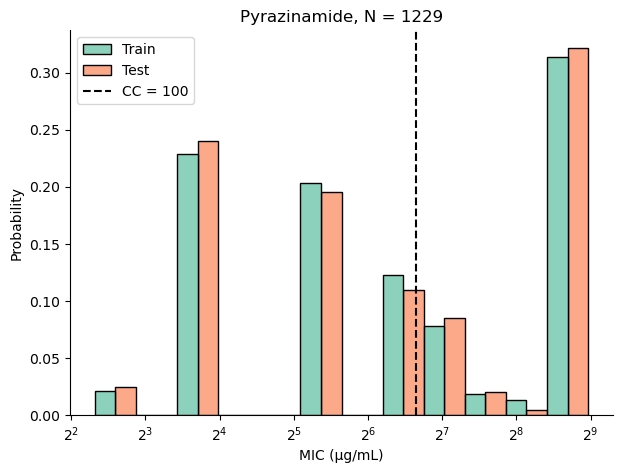

In [7]:
plot_MIC_dist("PZA", 100, saveName="../analysis/Pyrazinamide/train_test_MICs.png")

# Train vs. Test vs. Validation MIC Distributions (ECDFs FOR SUPPLEMENT)

In [8]:
def compare_three_distributions_ecdf(drug, cc, saveName=None):
    
    df_train = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv"))

    if os.path.isfile(os.path.join(data_dir, drug, "validation_data_for_model.csv")):
        df_val = pd.read_csv(os.path.join(data_dir, drug, "validation_data_for_model.csv"))
    else:
        # don't use this function unless there is validation data. If there is not, use the function above
        return None
    
    df_combined = pd.concat([df_train[["ROLLINGDB_ID", f"{drug}_midpoint", "category"]], 
                             df_val[["ROLLINGDB_ID", f"{drug}_midpoint"]]
                            ], axis=0)

    df_combined["Dataset"] = df_combined["category"].map({"original_train_set": "Train", "original_test_set": "Test"})
    df_combined["Dataset"] = df_combined["Dataset"].fillna("Validation")
    del df_combined["category"]
    
    fig, ax = plt.subplots()
    
    sns.ecdfplot(data=df_combined,
                 x=f"{drug}_midpoint",
                 hue="Dataset",
                 hue_order=["Train", "Test", "Validation"],
                 log_scale=2,
                 ax=ax,
                 palette="Set2"
                )
        
    # Get the handles and labels from both legends
    handles, labels = plt.gca().get_legend().legendHandles, [t.get_text() for t in plt.gca().get_legend().get_texts()]
    
    # Add a legend that combines the handles and labels
    plt.legend(handles=handles + [plt.axvline(cc, color="black", linestyle="dashed", label=f"CC = {cc}")], labels=labels + [f"CC = {cc}"])
    sns.move_legend(ax, loc="lower right")
    sns.despine()
    
    if saveName is not None:
        plt.savefig(saveName, dpi=300)
    else:
        plt.show()
        
    pval = st.ks_2samp(np.log2(df_combined.query("Dataset=='Train'")[f"{drug}_midpoint"].values),
                np.log2(df_combined.query("Dataset=='Test'")[f"{drug}_midpoint"].values),
                alternative='two-sided'
               )[1]
    
    print(f"pval for Train/Test: {np.round(pval, 4)}")
    
    return df_combined

pval for Train/Test: 0.9999


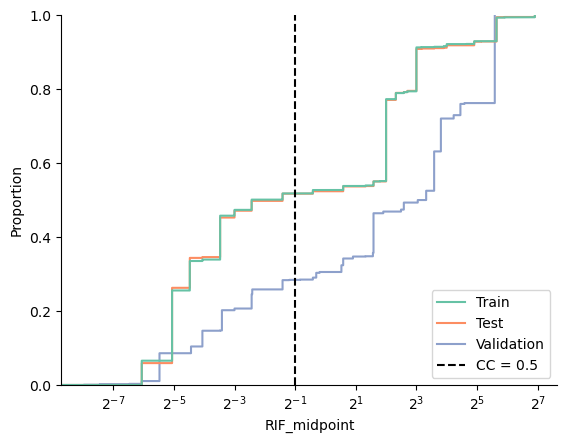

In [74]:
df_RIF = compare_three_distributions_ecdf("RIF", 0.5, saveName="../analysis/Rifampicin/MIC_ECDF.png")

pval for Train/Test: 0.9837


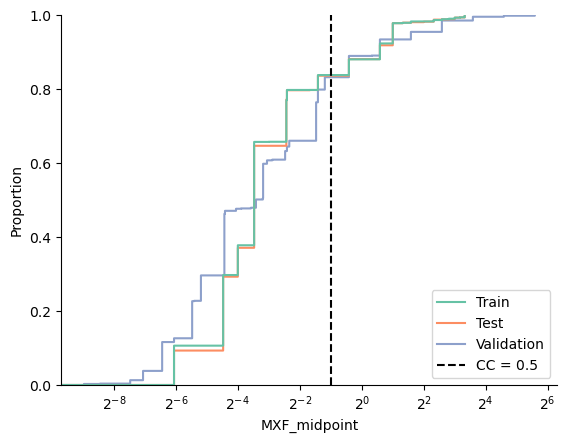

In [75]:
df_MXF = compare_three_distributions_ecdf("MXF", 0.5, saveName="../analysis/Moxifloxacin/MIC_ECDF.png")

pval for Train/Test: 0.9006


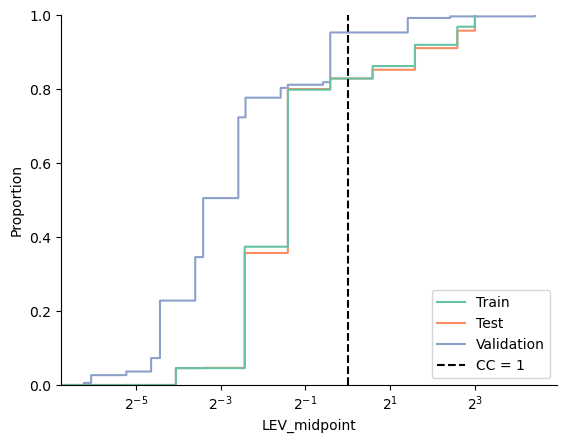

In [76]:
df_LEV = compare_three_distributions_ecdf("LEV", 1, saveName="../analysis/Levofloxacin/MIC_ECDF.png")

# Lineage Distributions

In [38]:
def get_lineage_summary(fName):

    df = pd.read_csv(fName)

    # already merged with the training set so that we could stratify the train/test sets by binary phenotype and primary lineage
    # so remove them
    if "Lineage" in df.columns:
        del df["Coll2014"]
        del df["Lineage"]
        
    df = df.merge(lineages, on="ROLLINGDB_ID", how="left")    
    assert len(df.loc[pd.isnull(df["Lineage"])]) == 0
    df["Lineage"] = df["Lineage"].replace("BOV", "M.bovis").replace("BOV_AFRI", "M.bovis")

    df_summary = df["Lineage"].value_counts().reset_index()
    df_summary.columns = ["Lineage", "Count"]
    df_summary = df_summary.sort_values("Lineage", ascending=True).reset_index(drop=True)
    df_summary["Lineage"] = df_summary["Lineage"].astype(str)

    return df_summary
    
    
    
def create_stacked_percent_bar_chart(drug, saveName=None):
    
    # LinToColor_Dict = {"1": "#f381b2",
    #                    "2": "#006dbb",
    #                    "3": "#9f5eab",
    #                    "4": "#f6472b",
    #                    "5": "#76400e",
    #                    "M. bovis": "white"
    #                   }

    LinToColor_Dict = {"1": "#DF83AC",
                       "2": "#7098CB",
                       "3": "#815D9F",
                       "4": "#E76956",
                       # "5": "#B67548",
                       # "6": "#6AB79E",
                       # "8": "#E4515B",
                       # "M.bovis": "white",
                      }

    df_lineage_summaries = pd.DataFrame(columns=["Dataset", "Lineage", "Count"])
        
    for fName in ["data_for_model.csv", "validation_data_for_model.csv", ]:

        df_summary = get_lineage_summary(os.path.join(data_dir, drug, fName))

        if "validation" in fName:
            df_summary["Dataset"] = "Validation"
        else:
            df_summary["Dataset"] = "Training"
    
        df_lineage_summaries = pd.concat([df_lineage_summaries, df_summary])

    lineage_stacked_for_plotting = df_lineage_summaries.pivot(index="Dataset", columns=["Lineage"], values="Count")
    lineage_stacked_for_plotting["Total"] = lineage_stacked_for_plotting.sum(axis=1)
    lineage_stacked_for_plotting = lineage_stacked_for_plotting.fillna(0)
    
    # compute proportions for plotting
    for lineage in lineage_stacked_for_plotting.columns:
        lineage_stacked_for_plotting[lineage] = lineage_stacked_for_plotting[lineage] / lineage_stacked_for_plotting["Total"]
        
    del lineage_stacked_for_plotting["Total"]
    lineage_stacked_for_plotting = lineage_stacked_for_plotting.reset_index().melt(id_vars="Dataset")
        
    # keep track of all the groups to increase the start value of the next bar
    prev_vals_array = np.zeros(len(lineage_stacked_for_plotting["Dataset"].unique()))
    
    # order in increasing lineage abundance for each drug
    lineage_stacked_for_plotting = lineage_stacked_for_plotting.sort_values(["Dataset", "value"], ascending=[True, False])
    
    # iterate through the Lineages and convert to percentages
    lineage_order = list(LinToColor_Dict.keys())[::-1] #lineage_stacked_for_plotting["Lineage"].unique()
    lineage_order = [val for val in lineage_order if val in lineage_stacked_for_plotting.Lineage.values]
    
    # set the figure size
    fig, ax = plt.subplots(figsize=(2.5, 4))
    
    for i, lineage in enumerate(lineage_order):  
                    
        # dataframe of proportion of each drug's samples that belong to the current lineage
        single_group = lineage_stacked_for_plotting[lineage_stacked_for_plotting["Lineage"]==lineage].groupby("Dataset")["value"].sum().reset_index()
        
        if i > 0:
            prev_vals = lineage_stacked_for_plotting[lineage_stacked_for_plotting["Lineage"]==lineage_order[i-1]].groupby("Dataset")["value"].sum().reset_index()
            prev_vals = prev_vals["value"].values
            prev_vals_array += prev_vals
            
        ax.bar(single_group["Dataset"].values, 
               single_group["value"].values, 
               color=LinToColor_Dict[lineage], 
               bottom = prev_vals_array, 
               edgecolor="black",
               label=lineage,
               width=0.5
              )        

    label_loc = 'center'
    sigfig = 2
    font_size = '9'
    
    for cont in ax.containers:
        labels = [np.round(val, sigfig) if val >= 0.05 else "" for val in cont.datavalues]    
        ax.bar_label(cont, labels=labels, label_type=label_loc, fontsize=font_size)
    
    plt.ylabel("Proportion")
    plt.setp(ax.patches, linewidth=0.75)
    sns.despine()
    
    # bar_scale = 0.85
    # for patch in ax.patches:
    #     current_width = patch.get_width()
    #     patch.set_width(current_width * bar_scale)
    
    # Rearrange the handles and labels
    handles, labels = ax.get_legend_handles_labels()    
    handles_labels_dict = dict(zip(labels, handles))
    handles_labels_dict = {key: val for key, val in handles_labels_dict.items() if key in lineage_order}
    handles_labels_dict = collections.OrderedDict(sorted(handles_labels_dict.items()))

    # Create the legend with the rearranged handles and labels
    ax.legend(list(handles_labels_dict.values()), list(handles_labels_dict.keys()))
    sns.move_legend(ax, fontsize=8, title='Lineage', loc='upper right',
                    ncol=len(lineage_order),
                   bbox_to_anchor=(1, -0.1))

    if saveName is not None:
        plt.savefig(saveName, dpi=300, bbox_inches='tight')
    else:
        plt.show()

    return df_lineage_summaries

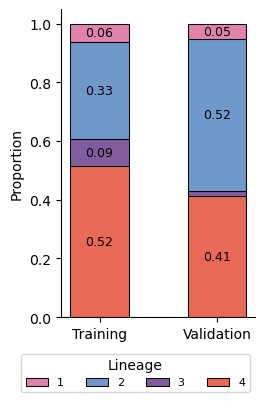

In [15]:
RIF_lineages = create_stacked_percent_bar_chart("RIF", saveName="../analysis/Rifampicin/train_val_lineages.png")

In [39]:
def create_stacked_percent_bar_chart_train_test(drugs_lst, saveName=None):
    
    # LinToColor_Dict = {"1": "#f381b2",
    #                    "2": "#006dbb",
    #                    "3": "#9f5eab",
    #                    "4": "#f6472b",
    #                    "5": "#76400e",
    #                    "M. bovis": "white"
    #                   }

    LinToColor_Dict = {"1": "#DF83AC",
                       "2": "#7098CB",
                       "3": "#815D9F",
                       "4": "#E76956",
                       # "5": "#B67548",
                       # "6": "#6AB79E",
                       # "8": "#E4515B",
                       # "M.bovis": "white",
                      }

    df_lineage_summaries = pd.DataFrame(columns=["Lineage", "Count"])
        
    for drug in drugs_lst:
        df_summary = get_lineage_summary(os.path.join(data_dir, drug, "data_for_model.csv"))
        df_summary["Drug"] = drug
        df_lineage_summaries = pd.concat([df_lineage_summaries, df_summary])

    lineage_stacked_for_plotting = df_lineage_summaries.pivot(index="Drug", columns=["Lineage"], values="Count")
    lineage_stacked_for_plotting["Total"] = lineage_stacked_for_plotting.sum(axis=1)
    lineage_stacked_for_plotting = lineage_stacked_for_plotting.fillna(0)
    
    # compute proportions for plotting
    for lineage in lineage_stacked_for_plotting.columns:
        lineage_stacked_for_plotting[lineage] = lineage_stacked_for_plotting[lineage] / lineage_stacked_for_plotting["Total"]
        
    del lineage_stacked_for_plotting["Total"]
    lineage_stacked_for_plotting = lineage_stacked_for_plotting.reset_index().melt(id_vars="Drug")
        
    # keep track of all the groups to increase the start value of the next bar
    prev_vals_array = np.zeros(len(lineage_stacked_for_plotting["Drug"].unique()))
    
    # order in increasing lineage abundance for each drug
    lineage_stacked_for_plotting = lineage_stacked_for_plotting.sort_values(["Drug", "value"], ascending=[True, False])
    
    # iterate through the Lineages and convert to percentages
    lineage_order = list(LinToColor_Dict.keys())[::-1] #lineage_stacked_for_plotting["Lineage"].unique()
    lineage_order = [val for val in lineage_order if val in lineage_stacked_for_plotting.Lineage.values]
    
    # set the figure size
    fig, ax = plt.subplots(figsize=(5, 5))
    
    for i, lineage in enumerate(lineage_order):  
                    
        # dataframe of proportion of each drug's samples that belong to the current lineage
        # MAKE SURE TO HAVE THE LOC.[DRUGS_LST] LINE IN BOTH SINGLE_GROUP AND PREV_VALS TO MAINTAIN THE DRUG ORDERING
        single_group = lineage_stacked_for_plotting[lineage_stacked_for_plotting["Lineage"]==lineage].groupby("Drug")["value"].sum().loc[drugs_lst].reset_index()
        
        if i > 0:
            prev_vals = lineage_stacked_for_plotting[lineage_stacked_for_plotting["Lineage"]==lineage_order[i-1]].groupby("Drug")["value"].sum().loc[drugs_lst].reset_index()
            prev_vals = prev_vals["value"].values
            prev_vals_array += prev_vals
            
        ax.bar(single_group['Drug'].values, 
               single_group["value"].values, 
               color=LinToColor_Dict[lineage], 
               bottom = prev_vals_array, 
               edgecolor="black",
               label=lineage,
               width=0.5
              )        

    label_loc = 'center'
    sigfig = 2
    font_size = '9'
    
    for cont in ax.containers:
        labels = [np.round(val, sigfig) if val >= 0.05 else "" for val in cont.datavalues]    
        ax.bar_label(cont, labels=labels, label_type=label_loc, fontsize=font_size)
    
    plt.ylabel("Proportion")
    plt.setp(ax.patches, linewidth=0.75)
    sns.despine()
    
    # bar_scale = 0.85
    # for patch in ax.patches:
    #     current_width = patch.get_width()
    #     patch.set_width(current_width * bar_scale)
    
    # Rearrange the handles and labels
    handles, labels = ax.get_legend_handles_labels()    
    handles_labels_dict = dict(zip(labels, handles))
    handles_labels_dict = {key: val for key, val in handles_labels_dict.items() if key in lineage_order}
    handles_labels_dict = collections.OrderedDict(sorted(handles_labels_dict.items()))

    # Create the legend with the rearranged handles and labels
    ax.legend(list(handles_labels_dict.values()), list(handles_labels_dict.keys()))
    sns.move_legend(ax, fontsize=8, title='Lineage', loc='upper right',
                    ncol=1,#len(lineage_order),
                   #bbox_to_anchor=(0.85, -0.08),
                   bbox_to_anchor=(1.18, 0.6)
    )

    if saveName is not None:
        plt.savefig(saveName, dpi=300, bbox_inches='tight')
    else:
        plt.show()

    return df_lineage_summaries

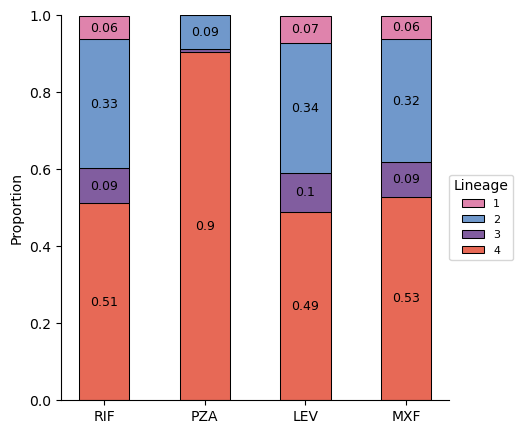

In [40]:
all_drug_lineages = create_stacked_percent_bar_chart_train_test(["RIF", "PZA", "LEV", "MXF"], saveName="fourDrug_lineage_summary.png")

In [5]:
def lineage_pie_chart(df, bbox=(1.4, 0.5)):

    # df_train = pd.read_csv(os.path.join(data_path, drug, "data_for_model.csv"))
    # df_val = pd.read_csv(os.path.join(data_path, drug, "validation_data_for_model.csv"))
    
    # Pie chart, where the slices will be ordered and plotted counter-clockwise:
    df_summary = df["Lineage"].value_counts().reset_index()
    df_summary.columns = ["Lineage", "Count"]
    df_summary = df_summary.sort_values("Lineage", ascending=True).reset_index(drop=True)
    df_summary["Lineage"] = df_summary["Lineage"].astype(str)

    fig, ax = plt.subplots(figsize=(9, 6))

    LinToColor_Dict = {"1": "#f381b2",
                       "2": "#006dbb",
                       "3": "#9f5eab",
                       "4": "#f6472b",
                       # "5": "#76400e",
                       # "6": "#36ba74",
                       # "7": "#ffb000",
                       "BOV_AFRI": "black",
                      }
    
    labels = df_summary["Lineage"]
    sizes = df_summary["Count"]
    colors = [LinToColor_Dict[lineage] for lineage in df_summary["Lineage"].values]

    wedge_sizes = 100.*sizes/sizes.sum()
    patches, texts = ax.pie(sizes, colors=colors, startangle=90, radius=1.2)
    labels = ['{0}: {1:1.2f} %'.format(i,j) for i,j in zip(labels, wedge_sizes)]

    sort_legend = False
    if sort_legend:
        patches, labels, dummy =  zip(*sorted(zip(patches, labels, sizes),
                                              key=lambda x: x[2],
                                              reverse=True))


    ax.legend(patches, labels)
    sns.move_legend(ax, fontsize=12, title='', loc='center right', bbox_to_anchor=bbox)
    
    plt.tight_layout()
    plt.show()
    # sns.despine()
    #plt.savefig("Figures/lineage_pie.png", dpi=400, bbox_inches='tight')

In [4]:
# lineage_pie_chart(df_rif_train, bbox=(1.3, 0.5))

In [5]:
# lineage_pie_chart(df_rif_val)

# Distribution of MIC vs. Unique Sequences

In [52]:
def make_boxplot_MIC_by_seq(drug, fasta_file, df_val=None, saveName=None):

    df = pd.read_csv(os.path.join(data_path, drug, "data_for_model.csv"))
    
    if df_val is None:
        df = df[["ROLLINGDB_ID", f"{drug}_midpoint", "Lineage"]]
    else:
        df = pd.concat([df[["ROLLINGDB_ID", f"{drug}_midpoint", "Lineage"]], df_val[["ROLLINGDB_ID", f"{drug}_midpoint", "Lineage"]]])

    fasta_seq = [(seq.id.split(".")[0], str(seq.seq)) for seq in SeqIO.parse(fasta_file, "fasta")]
    seq_df = pd.DataFrame(fasta_seq)
    seq_df.columns = ["ROLLINGDB_ID", "Seq"]
    df = seq_df.merge(df, on="ROLLINGDB_ID", how="inner")
    print(df.shape)
    
    seq_num_mapping = dict(zip(df.Seq.unique(), np.arange(len(df.Seq.unique())).astype(str)))
    df["Seq_Num"] = df["Seq"].map(seq_num_mapping)

    _, seq_counts = np.unique(df["Seq_Num"], return_counts=True)
    len(seq_counts), np.max(seq_counts)

    thresh = 30
    plot_df = df.groupby('Seq_Num').filter(lambda x: len(x) > thresh)
    print(len(plot_df))
    plot_df["log2_MIC"] = np.log2(plot_df[f"{drug}_midpoint"])
    seq_num_order = plot_df.groupby("Seq_Num")[f"{drug}_midpoint"].mean().sort_values(ascending=True).index.values
    
    fig, ax = plt.subplots(1, 1, figsize=(20, 6))
    
    width = 0.75
    
    sns.boxplot(data=plot_df,
                  x="Seq_Num",
                  y="log2_MIC",
                  order=seq_num_order,
                  fliersize=3,
                    linewidth=width,
                  dodge=True,
                # jitter=True,
                  color="cornflowerblue",
                boxprops={"edgecolor": "black", "linewidth": width},
                medianprops={"color": "black", "linewidth": width},
                whiskerprops={"color": "black", "linewidth": width},
                capprops={"color": "black", "linewidth": width},
                 flierprops={"marker": "o", "color": "black"},
                  ax=ax
                 )
    
    plt.xticks([], [])
    new_labels = [int(np.exp2(val)) if np.exp2(val) >= 1 else np.round(np.exp2(val), 2) for val in ax.get_yticks()]
    ax.set_yticks(ticks=ax.get_yticks(), labels=new_labels)
    plt.axhline(y=np.log2(0.5), color="tomato", linewidth=1, linestyle="--", label="CC = 0.5 µg/mL")
    
    plt.legend(loc="lower right")
    plt.xlabel("")
    plt.ylabel("MIC (µg/mL)")
    sns.despine()
    plt.title(f"{drug} MICs for {len(plot_df.Seq_Num.unique())} Sequences with at least {thresh} Isolates")

    if saveName is None:
        plt.show()
    else:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName, dpi=300)
        

(9137, 4)
5523


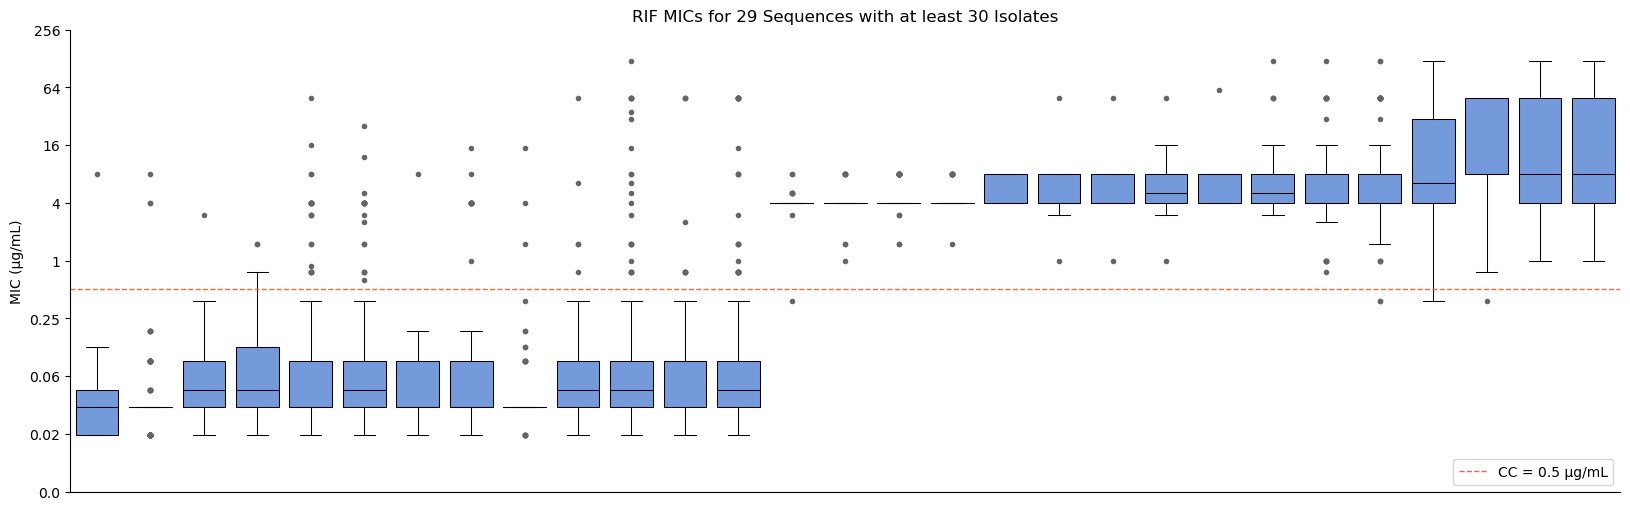

In [53]:
make_boxplot_MIC_by_seq("RIF",
                        "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas/rpoBC.fasta",
                        saveName="Rifampicin/boxplot_MICS_by_seq.png"
                       )

(7269, 4)
5834


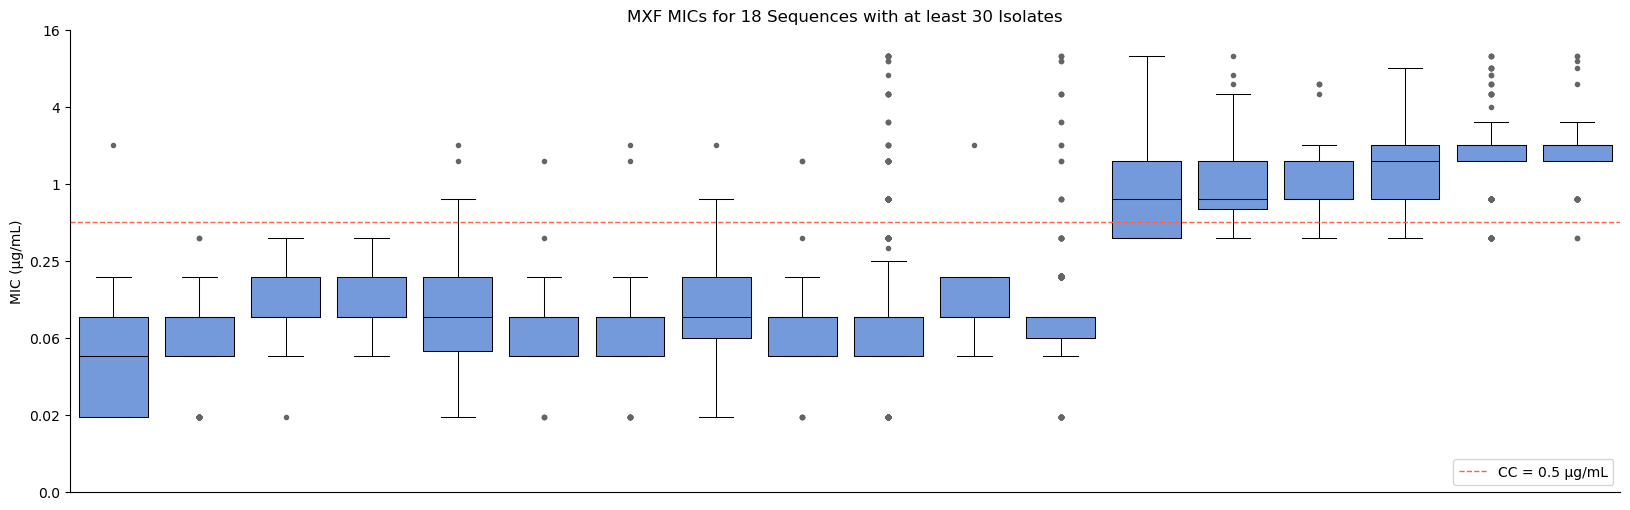

In [54]:
make_boxplot_MIC_by_seq("MXF",
                        "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas/gyrBA.fasta",
                        saveName="Moxifloxacin/boxplot_MICS_by_seq.png"
                       )

In [12]:
# sns.histplot(seq_counts, log_scale=10)
# sns.despine()
# plt.title(f"{len(seq_counts)} unique rpoBC Sequences")
# plt.show()

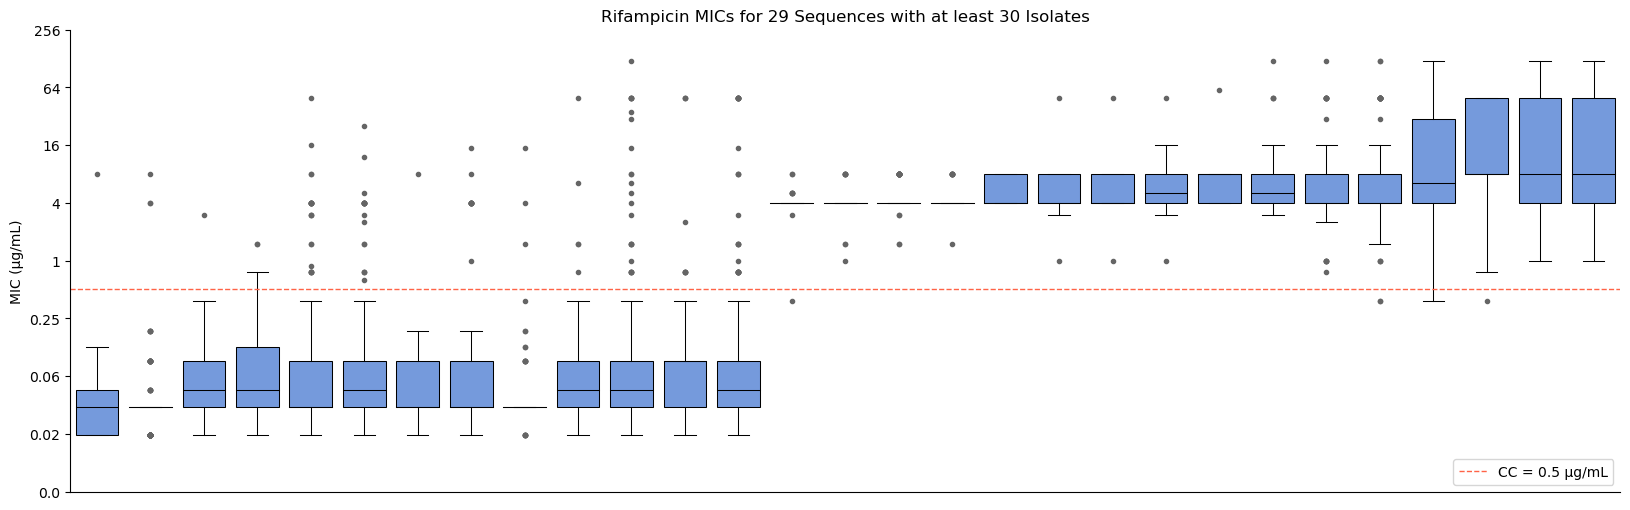

In [34]:
thresh = 30
plot_df = df_rif.groupby('Seq_Num').filter(lambda x: len(x) > thresh)
plot_df["log2-MIC"] = np.log2(plot_df["RIF_midpoint"])

# seq_num_order = plot_df['Seq_Num'].value_counts().to_frame().index.values.astype(str)
seq_num_order = plot_df.groupby("Seq_Num")["RIF_midpoint"].mean().sort_values(ascending=True).index.values

fig, ax = plt.subplots(1, 1, figsize=(20, 6))

width = 0.75

sns.boxplot(data=plot_df,
              x="Seq_Num",
              y="log2-MIC",
              order=seq_num_order,
              fliersize=3,
                linewidth=width,
              dodge=True,
            # jitter=True,
              color="cornflowerblue",
            boxprops={"edgecolor": "black", "linewidth": width},
            medianprops={"color": "black", "linewidth": width},
            whiskerprops={"color": "black", "linewidth": width},
            capprops={"color": "black", "linewidth": width},
             flierprops={"marker": "o", "color": "black"},
              ax=ax
             )

# # weird looking because the MICs are discretized, so they just form levels
# sns.stripplot(data=plot_df,
#               x="Seq_Num",
#               y="log2-MIC",
#               size=4,
#               order=seq_num_order,
#               jitter=True,
#               #inner="box",
#               color="black",
#               alpha=0.5,
#               ax=ax
#              )


plt.xticks([], [])
new_labels = [int(np.exp2(val)) if np.exp2(val) >= 1 else np.round(np.exp2(val), 2) for val in ax.get_yticks()]
ax.set_yticks(ticks=ax.get_yticks(), labels=new_labels)
plt.axhline(y=np.log2(0.5), color="tomato", linewidth=1, linestyle="--", label="CC = 0.5 µg/mL")

plt.legend(loc="lower right")
plt.xlabel("")
plt.ylabel("MIC (µg/mL)")
sns.despine()
plt.title(f"Rifampicin MICs for {len(plot_df.Seq_Num.unique())} Sequences with at least {thresh} Isolates")
#plt.show()
plt.savefig("Rifampicin/boxplot_MICS_by_seq.png", dpi=300)